## Visualizing earthquakes

Let's use Plotly to make an exploratory analysis of a dataset that gathers data from various incidents around the world, and in particular lots of earthquakes that have occured since 1965 !

The dataset is available on Kaggle, you can download it and you'll find a description here :  https://www.kaggle.com/usgs/earthquake-database

## Beginning with the dataset

1. Import pandas and the different packages of Plotly

In [5]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
# pio.renderers.default = "svg" # this line must be commented if working on colab

pd.options.display.max_columns = None

2. Read the file and show the first rows as well as basic statistics about the dataset

In [6]:
dataset = pd.read_csv("src/earthquakes.csv")

dataset.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [7]:
dataset.describe(include="all")

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
count,23409,23409,23409.000000,23409.000000,23409,23409.000000,4460.000000,7096.000000,23409.000000,23406,327.000000,2564.000000,7298.000000,1604.000000,1156.000000,17350.000000,23409,23409,23409,23409,23409
unique,12398,20469,NaN,NaN,4,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,23409,13,48,24,2
top,03/11/2011,14:09:03,NaN,NaN,Earthquake,NaN,NaN,NaN,NaN,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,US,US,US,Reviewed
freq,128,5,NaN,NaN,23229,NaN,NaN,NaN,NaN,7721,NaN,NaN,NaN,NaN,NaN,NaN,1,20627,20347,10457,20770
mean,NaN,NaN,1.678763,39.636726,NaN,70.748526,4.991118,275.362176,5.882558,NaN,0.071820,48.944618,44.165158,3.992660,7.662759,1.022766,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,30.113379,125.514881,NaN,122.605748,4.873905,162.152976,0.423084,NaN,0.051466,62.943106,32.143388,5.377262,10.430396,0.188544,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,-77.080000,-179.997000,NaN,-1.100000,0.000000,0.000000,5.500000,NaN,0.000000,0.000000,0.000000,0.004505,0.085000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,-18.652000,-76.352000,NaN,14.530000,1.800000,146.000000,5.600000,NaN,0.046000,10.000000,24.100000,0.968750,5.300000,0.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,-3.569000,103.981000,NaN,33.000000,3.500000,255.000000,5.700000,NaN,0.059000,28.000000,36.000000,2.319500,6.700000,1.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,26.188000,145.027000,NaN,54.000000,6.300000,384.000000,6.000000,NaN,0.075500,66.000000,54.000000,4.724500,8.100000,1.130000,NaN,NaN,NaN,NaN,NaN


3. In the following, we will use a lot the `Date` column. To avoid problems with your visualizations, use pandas to convert this column into `Datetime` type :

In [8]:
dataset.loc[:,'Date'] = pd.to_datetime(dataset['Date'])
dataset = dataset.sort_values(by = 'Date')
dataset.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,1965-01-02,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,1965-01-04,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,1965-01-05,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,1965-01-08,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,1965-01-09,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


## Exploring the number of observations over time

4. Make a simple plot with plotly express to display the number of observed events as a function of time

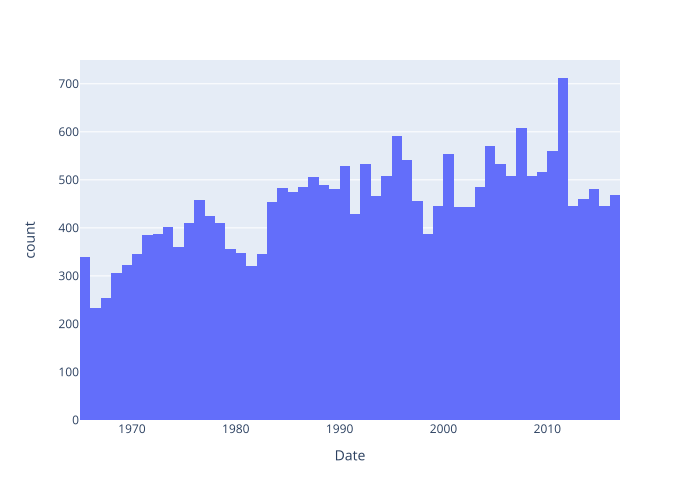

In [5]:
fig = px.histogram(dataset,'Date')
fig.show()

If the `Date` column was converted into `Datetime`, plotly handles it and has automatically set the number of bins such that the counts are made by year. This makes the histogram easily readable.

In the following, you will create customized plots with plotly.graph_objects to display more accurate information about the number of events.

5. With plotly.graph_objects, create a histogram with a range slider such that you can visualize the daily number of events

In [6]:
fig = go.Figure(
    data = go.Histogram(
        x = dataset['Date'], nbinsx = dataset['Date'].nunique()),
    layout = go.Layout(
        title = go.layout.Title(text = "Number of observations per day", x = 0.5),
        xaxis = go.layout.XAxis(title = 'X', rangeslider = go.layout.xaxis.Rangeslider(visible = True))
    )
)

fig.show()

6. We would like to check if there's some seasonality in the number of events. Create new columns in the dataset with the id of the month and year. Then use plotly's `make_subplots` function to display the monthly number of observations over a given year, independently for each of the five last years (so, there will be 5 independent histograms)

In [7]:
dataset.loc[:, 'Year'] = dataset['Date'].dt.year
dataset.loc[:, 'Month'] = dataset['Date'].dt.month
dataset.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status,Year,Month
0,1965-01-02,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic,1965,1
1,1965-01-04,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic,1965,1
2,1965-01-05,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic,1965,1
3,1965-01-08,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic,1965,1
4,1965-01-09,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic,1965,1


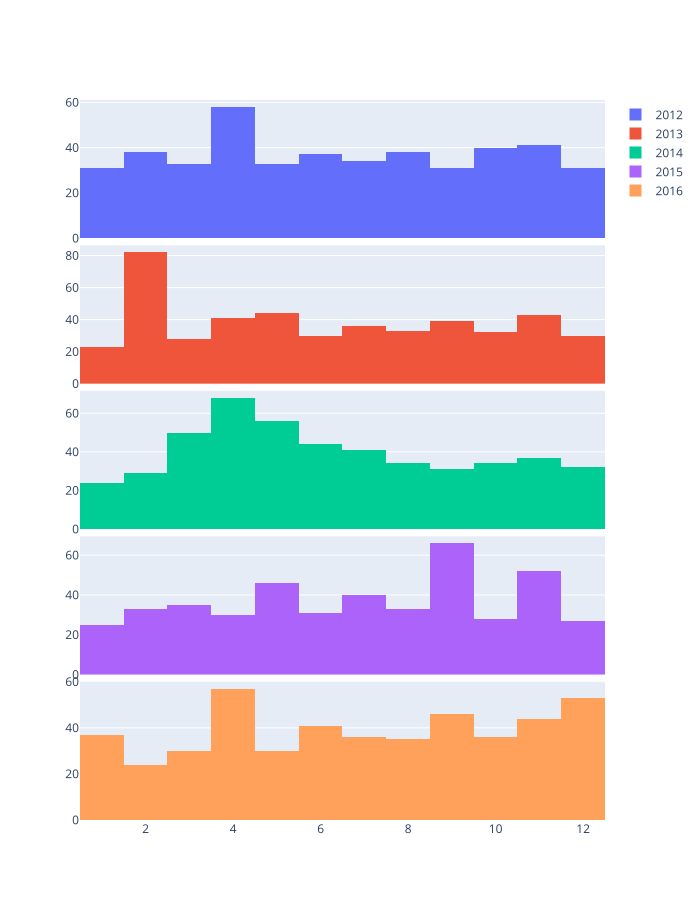

In [8]:
last_years = [2012, 2013, 2014, 2015, 2016]

fig = make_subplots(rows = 5, cols = 1, shared_xaxes = True, vertical_spacing = 0.01)

for i in range(len(last_years)):
    fig.add_trace(
        go.Histogram(
            x = dataset.loc[dataset['Year'] == last_years[i] ,'Month'],
        name = str(last_years[i])),
        row = i + 1,
        col = 1
    )

fig.update_layout(
    autosize=False,
    height=900)
fig.show()

7. Now, we would like to allow the user to choose a specific year among the five last years, and display the daily number of observations fot this year only. Use the `Updatemenu` and `Button` classes together with `add_trace` to create an interactive visualization.

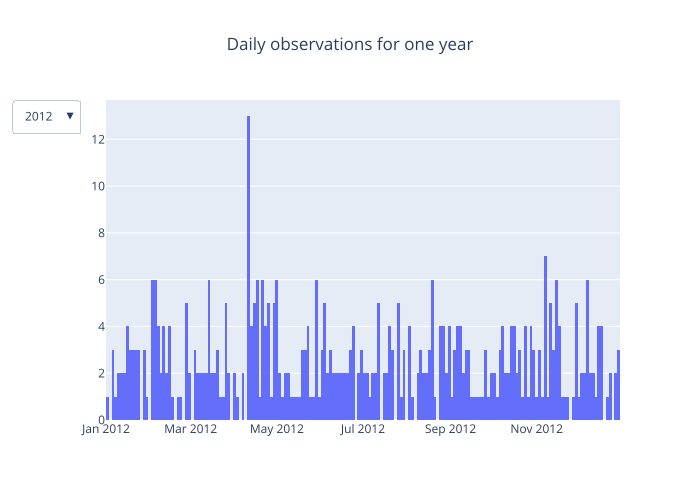

In [9]:
last_years = [2012, 2013, 2014, 2015, 2016]

fig = go.Figure()

for i in range(len(last_years)):
    if i == 0:
        fig.add_trace(
            go.Histogram(
                x = dataset.loc[dataset['Year']==last_years[i], 'Date'],
                nbinsx = dataset.loc[dataset['Year']==last_years[i], 'Date'].nunique(),
                visible=True))
    else:
        fig.add_trace(
            go.Histogram(
                x = dataset.loc[dataset['Year']==last_years[i], 'Date'],
                nbinsx = dataset.loc[dataset['Year']==last_years[i], 'Date'].nunique(),
                visible=False))


fig.update_layout(
        title = go.layout.Title(text = "Daily observations for one year", x = 0.5),
        showlegend = False)

fig.update_layout(
    updatemenus = [go.layout.Updatemenu(
        active = 0,
        buttons = [
                    go.layout.updatemenu.Button(
                        label = "2012",
                        method = "update",
                        args = [{"visible" : [True, False, False, False, False]}]),
                    go.layout.updatemenu.Button(
                            label = "2013",
                            method = "update",
                            args = [{"visible" : [False, True, False, False, False]}]),
                    go.layout.updatemenu.Button(
                            label = "2014",
                            method = "update",
                            args = [{"visible" : [False, False, True, False, False]}]),
                    go.layout.updatemenu.Button(
                            label = "2015",
                            method = "update",
                            args = [{"visible" : [False, False, False, True, False]}]),
                    go.layout.updatemenu.Button(
                            label = "2016",
                            method = "update",
                            args = [{"visible" : [False, False, False, False, True]}])
                ]
    )]
)

## Focusing on earthquakes

8. Use plotly express to display the proportions of each type of events in the dataset

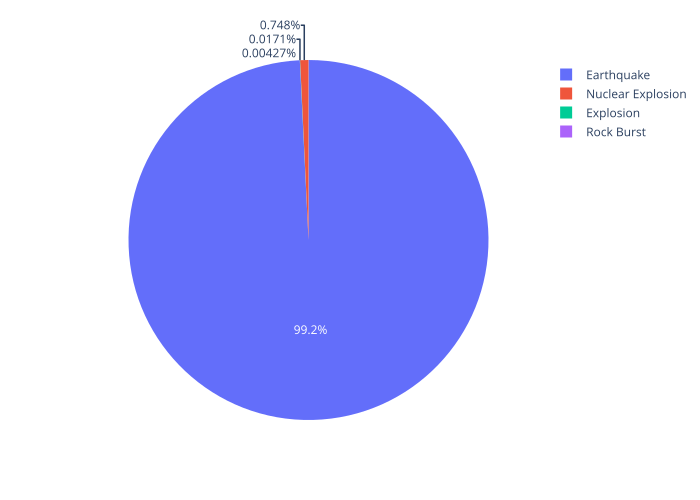

In [10]:
px.pie(dataset, names='Type')

From now, we will focus only on earthquakes.

9. Create a new dataset containing only earthquakes and plot the distribution of their magnitudes depths

In [11]:
earthquakes = dataset.loc[dataset['Type'] == 'Earthquake',:]
dataset.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status,Year,Month
0,1965-01-02,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic,1965,1
1,1965-01-04,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic,1965,1
2,1965-01-05,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic,1965,1
3,1965-01-08,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic,1965,1
4,1965-01-09,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,NaN,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic,1965,1


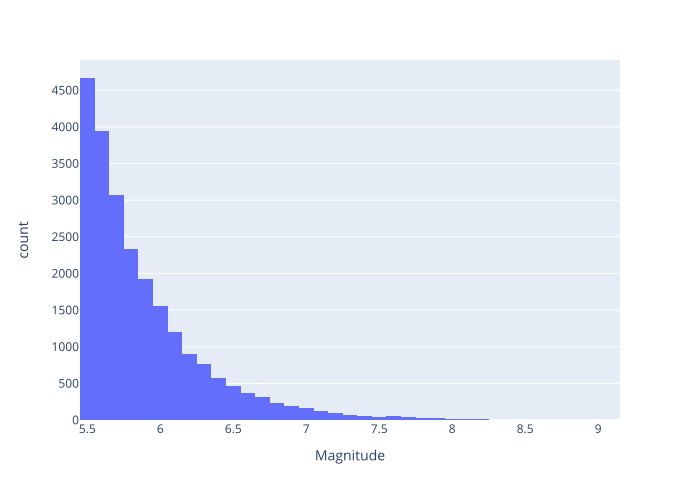

In [12]:
px.histogram(earthquakes, x = 'Magnitude', nbins=50)

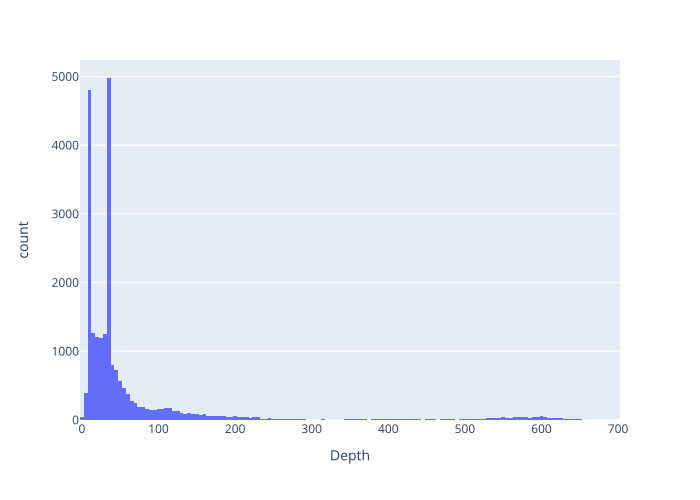

In [13]:
px.histogram(earthquakes, x = 'Depth')

10. Now, we'd like to explore the evolution of the magnitudes as a function of time :


- Create a dataframe containing the mean magnitudes per day
- Then use this dataset to display the mean magnitudes per day, with a range slider allowing the user to navigate among the dates
- Add a reference line showing the value of the mean magnitude computed over the whole dataset


In [14]:
mean_mag_date = earthquakes.groupby('Date')['Magnitude'].mean().reset_index(drop=False)
mean_mag_date.sort_values(by='Date')
mean_mag_date.head()

,Date,Magnitude
0,1965-01-02,6.0
1,1965-01-04,5.8
2,1965-01-05,6.2
3,1965-01-08,5.8
4,1965-01-09,5.8


In [15]:
fig = go.Figure(
    data = go.Scatter(
        x = mean_mag_date['Date'],
        y = mean_mag_date['Magnitude']),
    layout = go.Layout(
        title = go.layout.Title(text = "Mean magnitude per day", x = 0.5),
        xaxis = go.layout.XAxis(title = 'X', rangeslider = go.layout.xaxis.Rangeslider(visible = True))
    )
)

mean_mag_date.loc[:,'Mean_Magnitude'] = mean_mag_date['Magnitude'].mean()

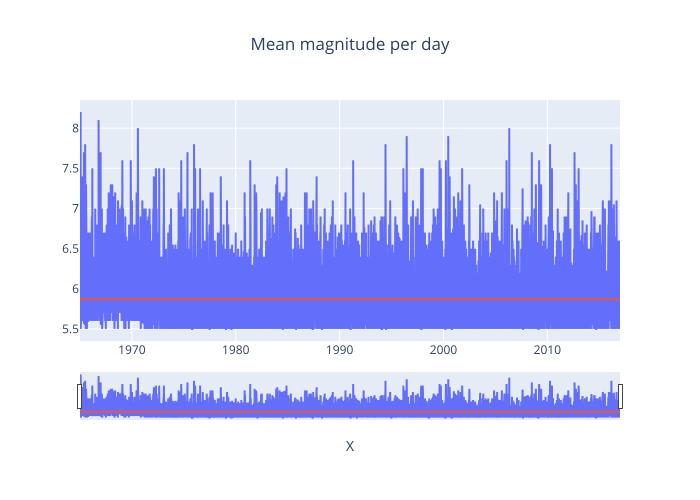

In [16]:
fig.add_trace(
    go.Scatter(
        x = mean_mag_date['Date'],
        y = mean_mag_date['Mean_Magnitude'])
)

fig.update_layout(showlegend = False)

fig.show()

To finish, let's visualize the distribution of the earthquakes around the world.

11. Use plotly express' `scatter_mapbox` to display the earthquakes on a map. Change the color of the markers depending on the value of the magnitude. Use the documentation and [this page](https://plotly.com/python/builtin-colorscales/) to find a suitable colorscale.

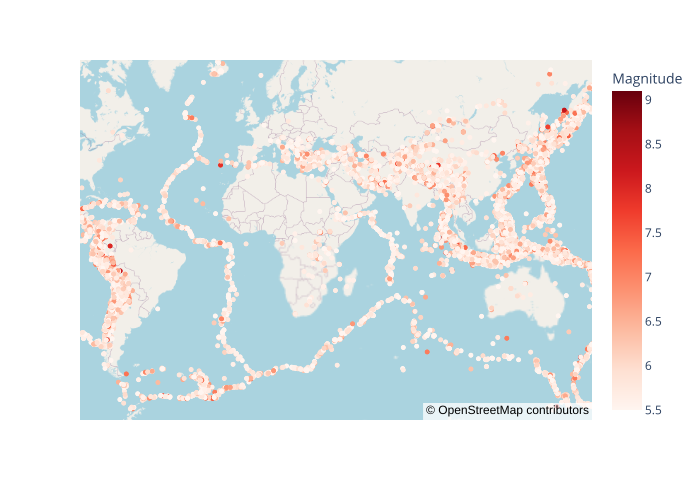

In [17]:
fig = px.scatter_mapbox(earthquakes, lat="Latitude", lon="Longitude", color="Magnitude",
                        mapbox_style="open-street-map", zoom = 0.5, color_continuous_scale = 'Reds')
fig.show()

12. Let's make the map animated ! Add some arguments in `scatter_mapbox` to create an animation displaying the earthquakes year by year

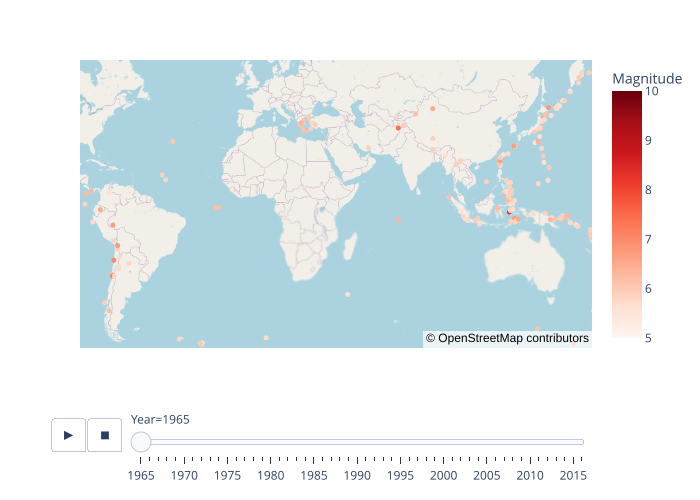

In [18]:
fig = px.scatter_mapbox(earthquakes, lat="Latitude", lon="Longitude", color="Magnitude", zoom = 0.5,
                        mapbox_style="open-street-map", color_continuous_scale = 'Reds', range_color = [5.0,10.0],
                       animation_frame = 'Year')
fig.show()

13. **Optional** Look for another function in plotly express that allows to display on a map the *density of earthquakes* (instead of each earthquake separately), and make it animated to display the evolution year by year.

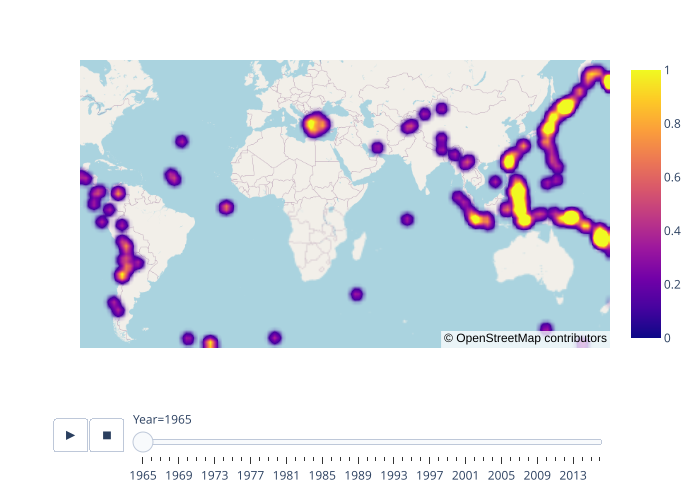

In [19]:
fig = px.density_mapbox(earthquakes, lat="Latitude", lon="Longitude", mapbox_style="open-street-map",
                       animation_frame = 'Year', zoom = 0.5, radius = 10)
fig.show()